In [1]:
import pandas as pd

order_fact = pd.read_parquet("../data_processed/order_fact.parquet")

order_fact.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,gmv,item_cnt,payment_total,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,38.71,1.0,38.71,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,141.46,1.0,141.46,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,179.12,1.0,179.12,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,72.20,1.0,72.20,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,28.62,1.0,28.62,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,2018-02


计算每月 GMV / 订单数 / 客单价。

In [2]:
monthly_metrics = (
    order_fact
    .groupby("order_month")
    .agg(
        total_gmv=("gmv", "sum"),
        order_cnt=("order_id", "nunique")
    )
    .reset_index()
)

monthly_metrics["AOV"] = monthly_metrics["total_gmv"] / monthly_metrics["order_cnt"]

monthly_metrics.head()

,order_month,total_gmv,order_cnt,AOV
0,2016-09,354.75,4,88.687500
1,2016-10,56808.84,324,175.335926
2,2016-12,19.62,1,19.620000
3,2017-01,137188.49,800,171.485613
4,2017-02,286280.62,1780,160.831809


可视化趋势。

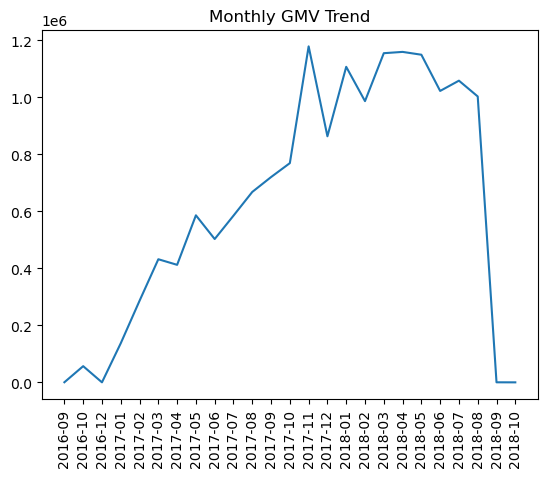

In [3]:
import matplotlib.pyplot as plt

monthly_metrics["order_month"] = monthly_metrics["order_month"].astype(str)

plt.figure()
plt.plot(monthly_metrics["order_month"], monthly_metrics["total_gmv"])
plt.xticks(rotation=90)
plt.title("Monthly GMV Trend")
plt.show()

复购率分析

计算用户订单次数。

In [4]:
customer_order_cnt = (
    order_fact
    .groupby("customer_unique_id")
    .agg(order_cnt=("order_id", "nunique"))
    .reset_index()
)

customer_order_cnt.head()

,customer_unique_id,order_cnt
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1


计算复购率。

In [5]:
repeat_rate = (customer_order_cnt["order_cnt"] > 1).mean()

print("复购率：", repeat_rate)

复购率： 0.031187562437562436
